In [4]:
%pylab notebook

Populating the interactive namespace from numpy and matplotlib


#### Must pip install astropy, lightkurve and PyAstronomy.pyasl

In [5]:
from astropy.table import Table
from astropy.time import Time
from astropy.io import ascii
import lightkurve as lk 
import warnings 
from lightkurve import search_targetpixelfile
import pandas as pd

###### uncomment the below if not using magic: ######
# import matplotlib.pyplot as plt
# import numpy as np

#### Searching and retrieving the light curve(s) of a star:

In [6]:
#######EDITABLE#######
#Insert the name of the star of interest below inbetween the red quotes.
star_name = 'TIC349059354' #what the catalogue contains
file_name = 'TIC354' #must contain NO spaces or file extension
Gaia_file_name = '5282555035278846976' #give Gaia FITS file (without extension)

In [7]:
#Finding star
search_result = lk.search_lightcurve(star_name, mission = 'TESS')

In [8]:
#Showing available data
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,SPOC,120,349059354,0.0
1,TESS Sector 05,2018,SPOC,120,349059354,0.0
2,TESS Sector 06,2018,SPOC,120,349059354,0.0
3,TESS Sector 12,2019,SPOC,120,349059354,0.0
4,TESS Sector 13,2019,SPOC,120,349059354,0.0
5,TESS Sector 69,2023,SPOC,120,349059354,0.0
6,TESS Sector 61,2023,SPOC,120,349059354,0.0
7,TESS Sector 68,2023,SPOC,120,349059354,0.0
8,TESS Sector 63,2023,SPOC,120,349059354,0.0


In [9]:
#######EDITABLE#######
#Enter what parameters to narrow down data downloaded
#Specify in ''!!!

exptime = 120 # specify the exposure time (s) - just like cadance

quarter = None # specify the sector

author = 'SPOC' # specify the author

radius=None # default is 0.0001 arcsec (conesearch)

limit=None # Maximum number of products to return

In [10]:
search_result = lk.search_lightcurve(star_name, mission = 'TESS',
                                     exptime=exptime,
                                     quarter=quarter,
                                     author= author,
                                     radius=radius,
                                     limit=limit)

print(search_result)

SearchResult containing 14 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   349059354      0.0
  1 TESS Sector 05 2018   SPOC     120   349059354      0.0
  2 TESS Sector 06 2018   SPOC     120   349059354      0.0
  3 TESS Sector 12 2019   SPOC     120   349059354      0.0
  4 TESS Sector 13 2019   SPOC     120   349059354      0.0
  5 TESS Sector 61 2023   SPOC     120   349059354      0.0
  6 TESS Sector 62 2023   SPOC     120   349059354      0.0
  7 TESS Sector 63 2023   SPOC     120   349059354      0.0
  8 TESS Sector 64 2023   SPOC     120   349059354      0.0
  9 TESS Sector 65 2023   SPOC     120   349059354      0.0
 10 TESS Sector 66 2023   SPOC     120   349059354      0.0
 11 TESS Sector 67 2023   SPOC     120   349059354      0.0
 12 TESS Sector 68 2023   SPOC     120   349059354      0

In [8]:
#Downloading filtered data
lc = search_result[0].download_all()
count_result = len(search_result) #number of search results

<IPython.core.display.Javascript object>


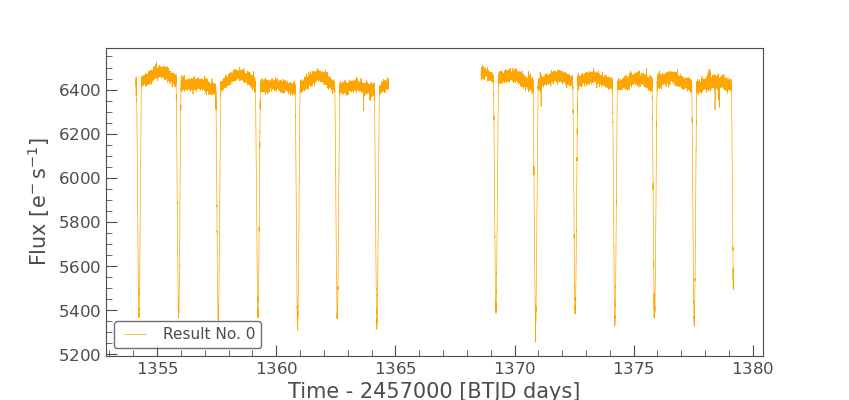

IndexError: list index out of range

In [9]:
#Displaying the data
for lightcurve in range(0,count_result):
    current = lc[lightcurve]
    current.plot(label='Result No. '+str(lightcurve),color='orange')
    plt.show()

In [10]:
#######EDITABLE#######
#Enter data that is not of interest 
#(i.e. those which, by eye, don't look to be of good quality)
unwanted = []

In [11]:
#########NOT EDITABLE: Only run if wanting to remove whole search results#########
#Showing and downloading the newly filtered results
wanted = []

for lightcurve in range(0,count_result):
    if lightcurve not in unwanted:
        wanted.append(lightcurve)

print(wanted)

search_result = search_result[wanted]
print(search_result) #printing updated list
lc = search_result.download_all() #downloading wanted lightcurves

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
SearchResult containing 14 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   349059354      0.0
  1 TESS Sector 05 2018   SPOC     120   349059354      0.0
  2 TESS Sector 06 2018   SPOC     120   349059354      0.0
  3 TESS Sector 12 2019   SPOC     120   349059354      0.0
  4 TESS Sector 13 2019   SPOC     120   349059354      0.0
  5 TESS Sector 61 2023   SPOC     120   349059354      0.0
  6 TESS Sector 62 2023   SPOC     120   349059354      0.0
  7 TESS Sector 63 2023   SPOC     120   349059354      0.0
  8 TESS Sector 64 2023   SPOC     120   349059354      0.0
  9 TESS Sector 65 2023   SPOC     120   349059354      0.0
 10 TESS Sector 66 2023   SPOC     120   349059354      0.0
 11 TESS Sector 67 2023   SPOC     120   349059354      0.0
 12 TESS S

<IPython.core.display.Javascript object>


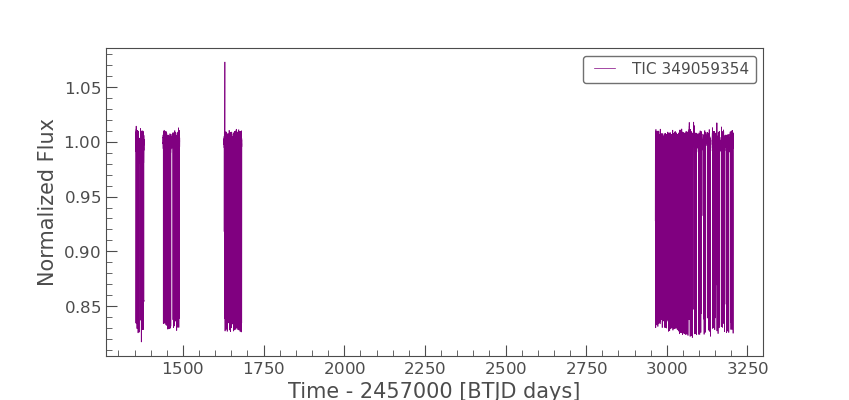

In [12]:
#Displaying light curve<s> of interest:
nlc = lc.stitch()
nlc.plot(color='purple')
plt.show()

#### Removing the messy bits

In [13]:
#######EDITABLE#######
#Examine the light curve(s) of interest above using the interactive plot tool.
#Insert the start and end time(s) of the unwanted patch(es) of data into the following variables respectively.
bad_dat_start_list = [1350,1630.07,1653.13,3068.3,3153.1] #The start times of individual unwanted patches are separated by ','.
bad_dat_end_list =  [1366.4,1630.097,1654.90,3095.9,3166.8]  #The end times of individual unwanted patches are separated by ','.

bad_flux_bottom = [1.094] #bottom (y values) of bad values
bad_flux_top = [1.2] # top (y values) of bad values

In [14]:
good_lc = nlc.copy()
for bad_dat_start,bad_dat_end in zip(bad_dat_start_list,bad_dat_end_list):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (good_lc.time.value < bad_dat_start) | (good_lc.time.value > bad_dat_end)
    good_lc = good_lc[good_data_mask]

for bad_dat_start,bad_dat_end in zip(bad_flux_bottom,bad_flux_top):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (good_lc.flux.value < bad_dat_start) | (good_lc.flux.value > bad_dat_end)
    good_lc = good_lc[good_data_mask]

Removing data from  1350  to  1366.4
Removing data from  1630.07  to  1630.097
Removing data from  1653.13  to  1654.9
Removing data from  3068.3  to  3095.9
Removing data from  3153.1  to  3166.8
Removing data from  1.094  to  1.2


<IPython.core.display.Javascript object>


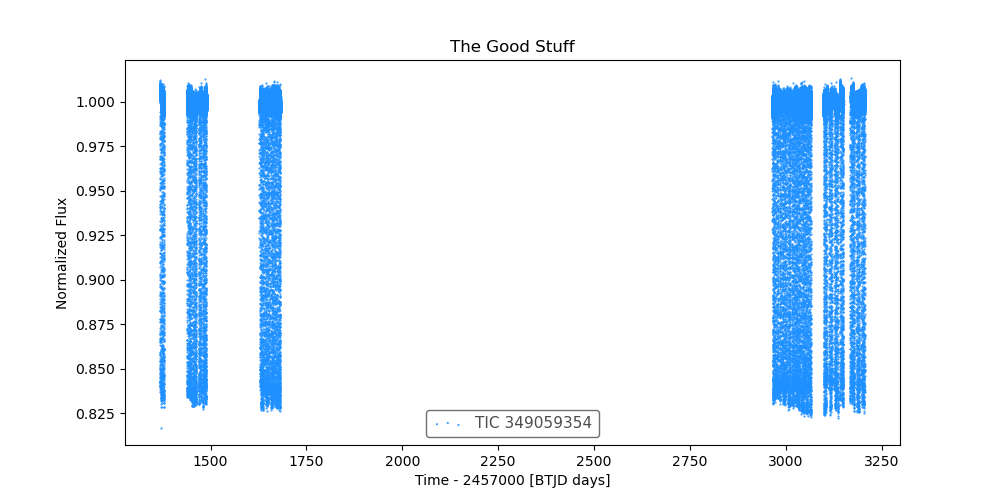

Text(0.5, 1.0, 'The Good Stuff')

In [15]:
#Plotting the good data
fig, ax = plt.subplots(figsize=(10,5))
good_lc.scatter(ax=ax, s=1, color='dodgerblue')
ax.set_title('The Good Stuff')    
#ax.set_xlim(0,1700)

#### Determining the orbital period of the star:

In [15]:
#######EDIT THIS#######

#Use the interactive plot tool to measure an estimate of the orbital period of the star.
#Insert this estimate along with a reasonable uncertainty in the corresponding variables below.


period_estimate = 1650.55-1647.22 #estimate in days
period_uncertainty = 0.1 #uncertainty in days

<IPython.core.display.Javascript object>


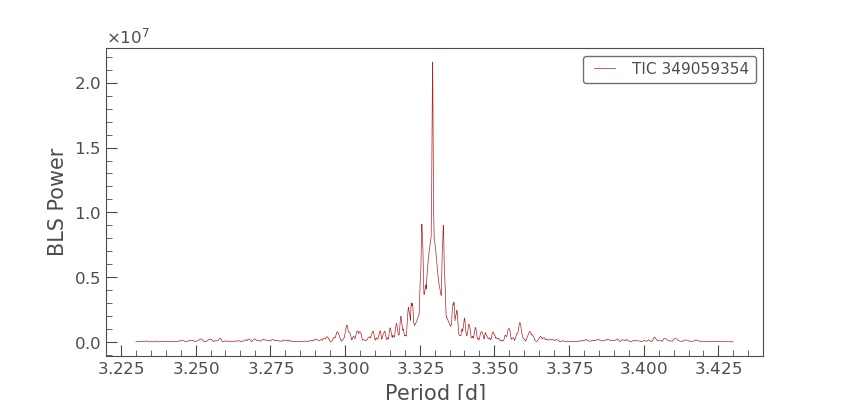

In [16]:
#Creating an array of periods to search
#This is where you go back to the third cell of this notebook and insert a period estimate and uncertainty.



period = np.linspace(period_estimate-period_uncertainty, period_estimate+period_uncertainty, 10000)

#Creating a BLSPeriodogram
bls = good_lc.to_periodogram(method='bls', period=period, frequency_factor=500);
bls.plot(color='firebrick');

In [17]:
orbital_period = bls.period_at_max_power
orbital_t0 = bls.transit_time_at_max_power
orbital_dur = bls.duration_at_max_power

#Displaying the most likely orbital period of the star
print(orbital_period)
print(orbital_t0)

3.3293299329932267 d
1370.8805176208737


<IPython.core.display.Javascript object>


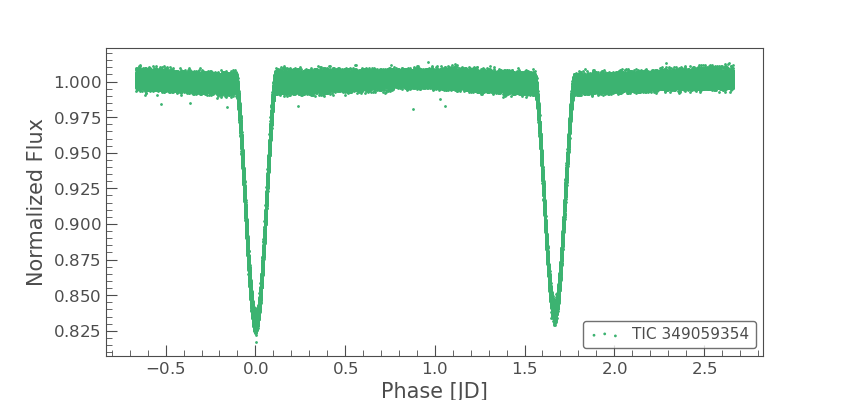

In [18]:
#Plotting a phase-folded light curve of the star
ax = good_lc.fold(period=orbital_period, epoch_time=orbital_t0,wrap_phase=0.8*orbital_period).scatter(color='mediumseagreen')
plt.show()

#### Comparing with raw Gaia data

In [19]:
# This is to import the .fits file with the gaia data and then getting the data into the 3 different colour bands for comparison
# with the phase folded lightcurve above.

table = Table.read(str(Gaia_file_name)+'.fits')

Gtable = table[table['band'] == 'G']  # Green 
BPtable = table[table['band'] == 'BP'] # Blue
RPtable = table[table['band'] == 'RP'] # Red
 
# Removing any masked values in the time, flux, and flux_error columns
Gtable = Gtable[~Gtable['time'].mask]
BPtable = BPtable[~BPtable['time'].mask]
RPtable = RPtable[~RPtable['time'].mask]
 
Gtable = Gtable[~Gtable['flux'].mask]  # Use flux instead of magnitude because no error for magnitude?
BPtable = BPtable[~BPtable['flux'].mask]  # Using flux instead of magnitude
RPtable = RPtable[~RPtable['flux'].mask]  # Using flux instead of magnitude
 
Gtable = Gtable[~Gtable['flux_error'].mask]
BPtable = BPtable[~BPtable['flux_error'].mask]
RPtable = RPtable[~RPtable['flux_error'].mask]
 
# Creating LightCurve objects from the data for each band (using flux directly)
Glc = lk.LightCurve(time=Gtable['time'].filled().value + 2455197.5, 
                    flux=Gtable['flux'].filled().value, 
                    flux_err=Gtable['flux_error'].filled().value)
Glc['time'].format='btjd'
 
BP_lc = lk.LightCurve(time=BPtable['time'].filled().value + 2455197.5, 
                      flux=BPtable['flux'].filled().value, 
                      flux_err=BPtable['flux_error'].filled().value)
BP_lc['time'].format='btjd'
 
RP_lc = lk.LightCurve(time=RPtable['time'].filled().value + 2455197.5, 
                      flux=RPtable['flux'].filled().value, 
                      flux_err=RPtable['flux_error'].filled().value)
RP_lc['time'].format='btjd'


In [20]:
# normalising the Gaia data.

nGlc = Glc.normalize()

nBP_lc = BP_lc.normalize()

nRP_lc = RP_lc.normalize()

In [21]:
# phase folding Gaia data and the good_lc to prepare for overplotting.

nGlc_pf = nGlc.fold(period=orbital_period, epoch_time=orbital_t0)

nRP_lc_pf = nRP_lc.fold(period=orbital_period, epoch_time=orbital_t0)

nBP_lc_pf = nBP_lc.fold(period=orbital_period, epoch_time=orbital_t0)

lc_after_pf = good_lc.fold(period=orbital_period, epoch_time=orbital_t0)

<IPython.core.display.Javascript object>


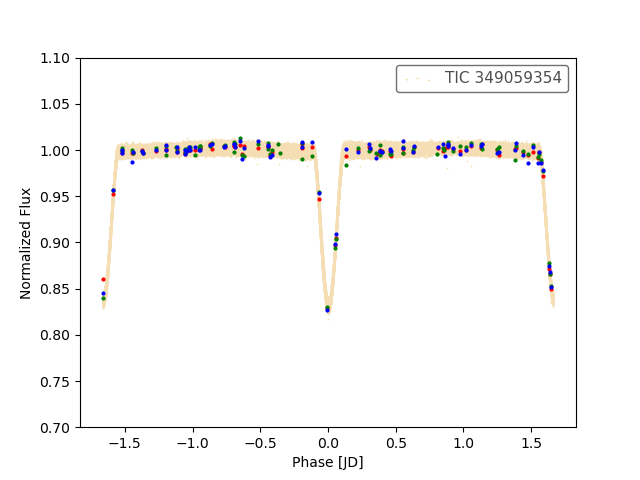

In [22]:
#overplotting the Gaia data with the phase folded lightcurve if they look similar then the data is good to use.

fig,ax = plt.subplots()
lc_after_pf.scatter(ax = ax, c = 'wheat',marker='+')
nRP_lc_pf.scatter(ax = ax, c= 'r',marker='o')
nGlc_pf.scatter(ax = ax, c = 'g',marker='o')
nBP_lc_pf.scatter(ax = ax, c = 'b',marker='o')
ax.set_ylim(0.7,1.1)

plt.show()

#### Detrending the light curve
- Change `polynomial_degree` to smaller if **poor fit**
- Change `gap_tol` if **error of no x values in array**

In [23]:
#####EDITABLE#####
#Adjust some of the parameters on the first three lines to get a good fit to your light curve.

n_cycle = 5             # recommended value = 2 - 5
rejection_limit = 4     # recommended value = 3 - 5
polynomial_degree =8   # recommended value = 2 - 16, do not use very high values (>~24)
gap_tol = 0.05       # recommended value = 0.005, smaller value => more gaps

In [24]:
# No user servicable parts inside this chunk of code
t =  good_lc.time.value
lc_sorted = good_lc[np.argsort(t)]
timeval =  lc_sorted.time.value
start_times = np.hstack([timeval.min(),timeval[np.gradient(timeval)>gap_tol][1::2]])
end_times = np.hstack([timeval[np.gradient(timeval)>gap_tol][0::2],timeval.max()])
smooth_function = np.ones_like(timeval)
plot_function = np.zeros_like(timeval) + np.nan
time_fit = np.array([])
flux_fit = np.array([])
for i,(t_min,t_max) in enumerate(zip(start_times,end_times)):
    j = (timeval >= t_min) & (timeval <= t_max)
    t_ref = np.median(timeval[j])
    x = timeval[j] - t_ref
    y = lc_sorted.flux.value[j]
    ft = np.ones_like(x) 
    if sum(j) > (polynomial_degree*2):
        for cycle in range(n_cycle):
            r = y/ft
            fit_mask = np.abs(r-1) < rejection_limit*np.mean(np.abs(r-1))
            x = x[fit_mask]
            y = y[fit_mask]
            poly_coeffs = np.polyfit(x, y, polynomial_degree)
            ft = np.polyval(poly_coeffs, x)
    time_fit = np.hstack([time_fit,x+t_ref])
    flux_fit = np.hstack([flux_fit,y])
    smooth_function[j] = np.polyval(poly_coeffs, timeval[j] - np.median(timeval[j]))
    # By using "<" in the second condition we leave an np.nan value in the array
    # at the gap position, so we get a gap in the plotted function.
    j = (timeval >= t_min) & (timeval < t_max)
    plot_function[j] =  np.polyval(poly_coeffs, timeval[j] - np.median(timeval[j]))
lc_after = lc_sorted / smooth_function

lc_after_1 = lc_after

##### Plot fit to trends in the data
 - Black points are data included in the polynomial fit
 - Grey points are points ignored in the polynomial fit
 - Red lines are the polynomials fits to each chunk of data

<IPython.core.display.Javascript object>


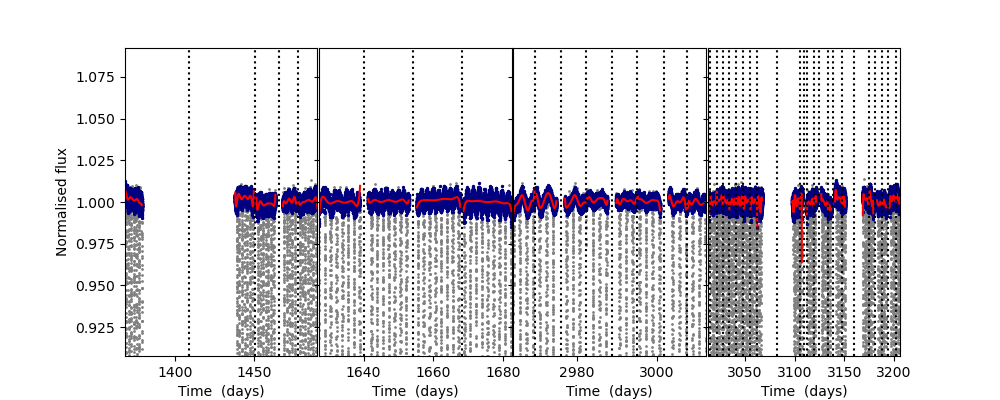

In [25]:
# Adjust figure size here, if needed
 
year = np.round((timeval-timeval.min())/365.25)
n_year = len(set(year))
fig,axlist = plt.subplots(ncols=n_year,figsize=(10,4),
                gridspec_kw = {'wspace':0.01},sharey=True)
 
for i,y in enumerate(set(year)):
    if n_year > 1:
        ax = axlist[i]
    else:
        ax = axlist
    j = year == y
    ax.scatter(timeval[j],good_lc.flux[j],s=1,color='grey')
    ax.scatter(time_fit,flux_fit,s=2,color='navy')
    ax.plot(timeval[j],plot_function[j],c='r')
    ax.set_xlabel('Time  (days)')
    if i == 0:
        r = np.max([2*np.ptp(smooth_function),3*np.std(flux_fit)])
        ax.set_ylim(1-r,1+r)
        ax.set_ylabel('Normalised flux')
    ax.set_xlim(timeval[j].min(),timeval[j].max())
    for t in (start_times[1:]+end_times[:-1])/2:
        ax.axvline(t,c='k',ls=':')
plt.show()    
 
# Uncomment this line and set file name if you want a copy of the figure for your report
#fig.savefig('trend_removal.png',dpi=144)

#### Remove points where the red curve is not flat (unconstrained)
- Change the polynomial fit if grey dots form
- Remove the data from that point if the red line suddenly jumps (as below)

In [26]:
#######EDITABLE#######
#Examine the light curve(s) of interest above using the interactive plot tool.
#Insert the start and end time(s) of the unwanted patch(es) of data into the following variables respectively.
bad_dat_start_list_2 = [3090,3167] #The start times of individual unwanted patches are separated by ','.
bad_dat_end_list_2 =  [3160,3180]  #The end times of individual unwanted patches are separated by ','.

In [27]:
lc_after = lc_after.copy()
for bad_dat_start,bad_dat_end in zip(bad_dat_start_list_2,bad_dat_end_list_2):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (lc_after.time.value < bad_dat_start) | (lc_after.time.value > bad_dat_end)
    lc_after = lc_after[good_data_mask]

Removing data from  3090  to  3160
Removing data from  3167  to  3180


<IPython.core.display.Javascript object>


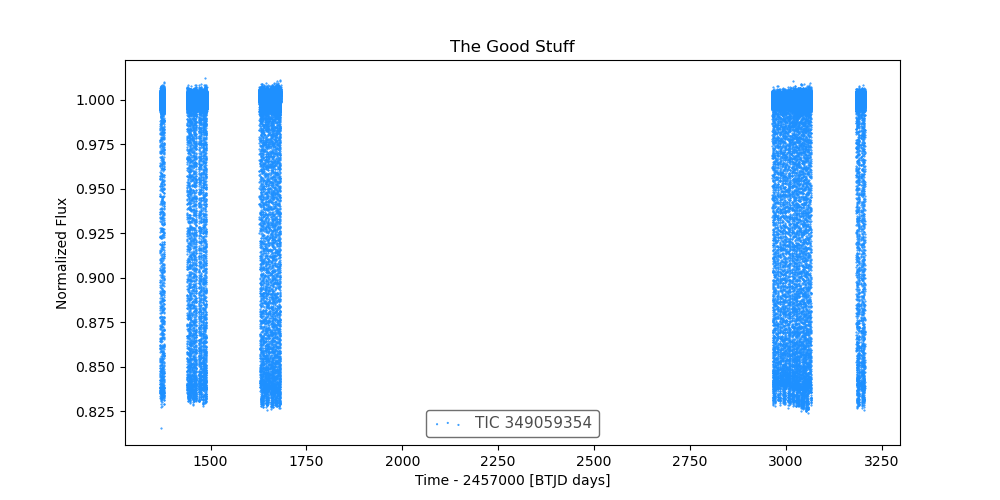

Text(0.5, 1.0, 'The Good Stuff')

In [28]:
#Plotting the good data
fig, ax = plt.subplots(figsize=(10,5))
lc_after.scatter(ax=ax, s=1, color='dodgerblue')
ax.set_title('The Good Stuff')    
#ax.set_xlim(0,1700)

#### Re-do Detrending

In [29]:
# No user serviceable parts inside this chunk of code
lc_after = lc_after.remove_nans() #removing nan values

t =  lc_after.time.value
lc_sorted1 = lc_after[np.argsort(t)]
timeval =  lc_sorted1.time.value
start_times = np.hstack([timeval.min(),timeval[np.gradient(timeval)>gap_tol][1::2]])
end_times = np.hstack([timeval[np.gradient(timeval)>gap_tol][0::2],timeval.max()])
smooth_function = np.ones_like(timeval)
plot_function = np.zeros_like(timeval) + np.nan
time_fit = np.array([])
flux_fit = np.array([])
for i,(t_min,t_max) in enumerate(zip(start_times,end_times)):
    j = (timeval >= t_min) & (timeval <= t_max)
    t_ref = np.median(timeval[j])
    x = timeval[j] - t_ref
    y = lc_sorted1.flux.value[j]
    ft = np.ones_like(x) 
    if sum(j) > (polynomial_degree*2):
        for cycle in range(n_cycle):
            r = y/ft
            fit_mask = np.abs(r-1) < rejection_limit*np.mean(np.abs(r-1))
            x = x[fit_mask]
            y = y[fit_mask]
            poly_coeffs = np.polyfit(x, y, polynomial_degree)
            ft = np.polyval(poly_coeffs, x)
    time_fit = np.hstack([time_fit,x+t_ref])
    flux_fit = np.hstack([flux_fit,y])
    smooth_function[j] = np.polyval(poly_coeffs, timeval[j] - np.median(timeval[j]))
    # By using "<" in the second condition we leave an np.nan value in the array
    # at the gap position, so we get a gap in the plotted function.
    j = (timeval >= t_min) & (timeval < t_max)
    plot_function[j] =  np.polyval(poly_coeffs, timeval[j] - np.median(timeval[j]))
lc_after = lc_sorted1 / smooth_function

##### Plot fit to trends in the data
 - Black points are data included in the polynomial fit
 - Grey points are points ignored in the polynomial fit
 - Red lines are the polynomials fits to each chunk of data

<IPython.core.display.Javascript object>


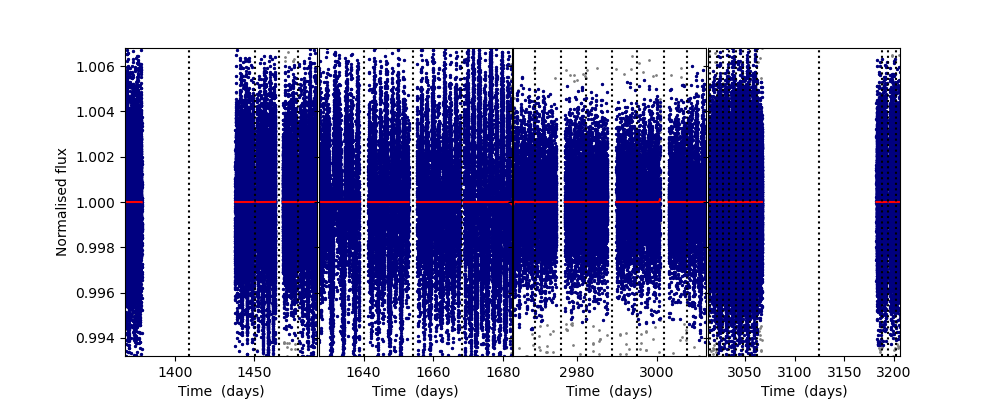

In [30]:
# Adjust figure size here, if needed
# Comparing ORIGINAL (before any removal of trends) to second trend removal
 
year = np.round((timeval-timeval.min())/365.25)
n_year = len(set(year))
fig,axlist = plt.subplots(ncols=n_year,figsize=(10,4),
                gridspec_kw = {'wspace':0.01},sharey=True)
 
for i,y in enumerate(set(year)):
    if n_year > 1:
        ax = axlist[i]
    else:
        ax = axlist
    j = year == y
    ax.scatter(timeval[j],lc_after.flux[j],s=1,color='grey')
    ax.scatter(time_fit,flux_fit,s=2,color='navy')
    ax.plot(timeval[j],plot_function[j],c='r')
    ax.set_xlabel('Time  (days)')
    if i == 0:
        r = np.max([2*np.ptp(smooth_function),3*np.std(flux_fit)])
        ax.set_ylim(1-r,1+r)
        ax.set_ylabel('Normalised flux')
    ax.set_xlim(timeval[j].min(),timeval[j].max())
    for t in (start_times[1:]+end_times[:-1])/2:
        ax.axvline(t,c='k',ls=':')

 
# Uncomment this line and set file name if you want a copy of the figure for your report
#fig.savefig('trend_removal.png',dpi=144)

#### Compare light curves before and after trend removal
**N.B. The graph here shows the improvement upon the previous detrending NOT the original**

<IPython.core.display.Javascript object>


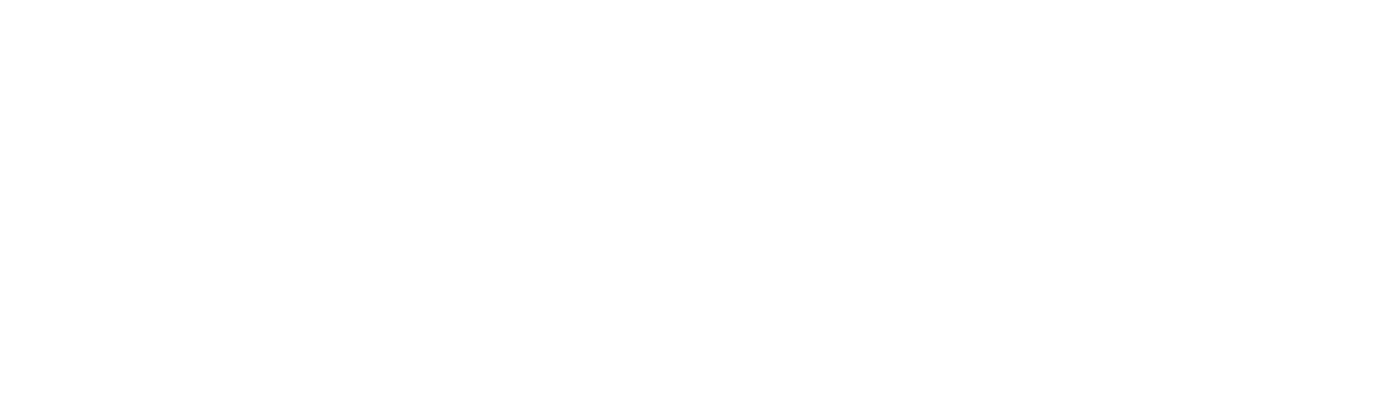

In [31]:
fig,axlist = plt.subplots(ncols=n_year,figsize=(14,4),
                gridspec_kw = {'wspace':0.01},sharey=True)
for i,y in enumerate(set(year)):
    ax = axlist[i]
    j = year == y
    if i == 0:
        lc_sorted1[j].scatter(ax=ax, s=1,c='r',label='Before')
        lc_after[j].scatter(ax=ax,s=1,c='b',label='After')
    else:
        lc_sorted1[j].scatter(ax=ax, s=1,c='r',label=None)
        lc_after[j].scatter(ax=ax,s=1,c='b',label=None)
        ax.set_ylabel(None)

#### Phase fold light curve again

<IPython.core.display.Javascript object>


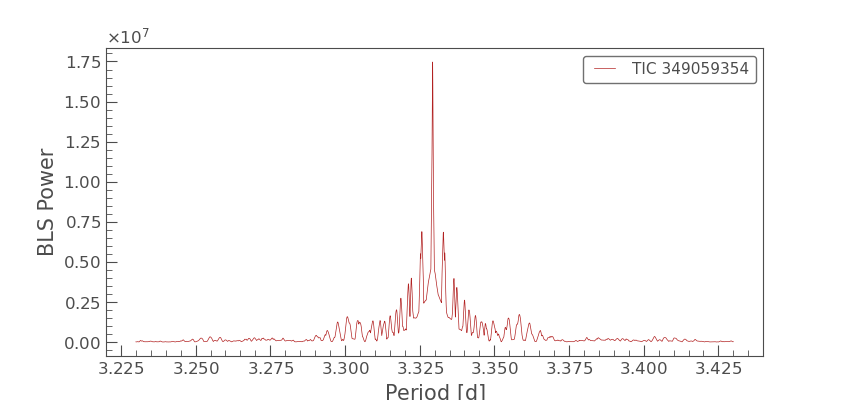

In [32]:
#Creating an array of periods to search
#This is where you go back to the third cell of this notebook and insert a period estimate and uncertainty.
period = np.linspace(period_estimate-period_uncertainty, period_estimate+period_uncertainty, 10000)

#Creating a BLSPeriodogram
bls = lc_after.to_periodogram(method='bls', period=period, frequency_factor=500);
bls.plot(color='firebrick');

In [33]:
orbital_period = bls.period_at_max_power
orbital_t0 = bls.transit_time_at_max_power
orbital_dur = bls.duration_at_max_power

#Displaying the most likely orbital period of the star
print(orbital_period)
print(orbital_t0)

3.3293299329932267 d
1369.2155176208737


<IPython.core.display.Javascript object>


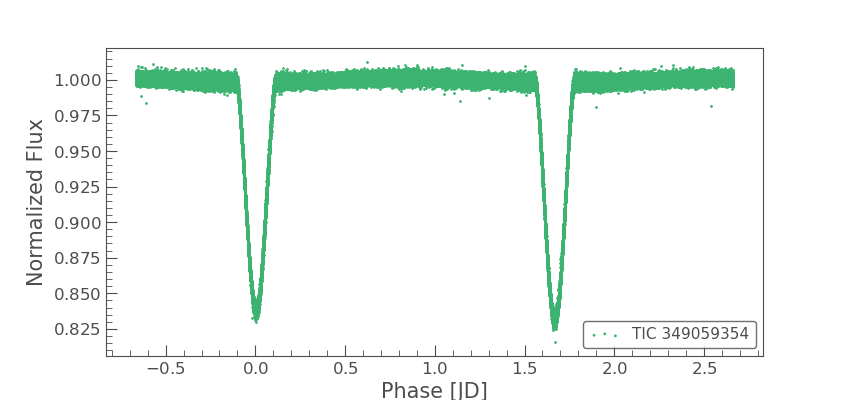

In [34]:
#Plotting a phase-folded light curve of the star
ax = lc_after.fold(period=orbital_period, epoch_time=orbital_t0,wrap_phase=0.8*orbital_period).scatter(color='mediumseagreen')
plt.show()

#### 

#### Did the trend removal work? 
##### Yes: Run the cell below
##### No: SKIP the cell below. Continue to next section

In [36]:
#ONLY run if happy with trend removal.
#If not, either:
# (a) skip this cell 
# (b) return to top of trend removal sequence to try the process again.
good_lc = lc_after

#### Create Mask for Eclipses
Look at the **phase folded lightcurve** and input values below for:
- Width of primary eclipse - this **must** include some flat area around the eclipse
- Width of secondary eclipse (or `None` if none)
- Phase of secondary eclipse (or `None` if none) - this is of the centre of the dip

All must be phases

In [39]:
primary_eclipse_width = 0.224 #width of primary eclipse
secondary_eclipse_width = 0.221 #width of secondary eclipse (if none, write `None`)
secondary_eclipse_phase_relative = 1.667 #phase of secondary eclipse (if none, write `None`), as seen in phase folded lightcurve x-coordinate

In [44]:
secondary_eclipse_phase = secondary_eclipse_phase_relative * (1/orbital_period)
orbital_t0 = orbital_t0
orbital_period = orbital_period

start_primary0 = orbital_t0 - (primary_eclipse_width)/2 #start of first eclipse
end_primary0 = orbital_t0 + (primary_eclipse_width)/2 #end of first eclipse

end_sequence = max(good_lc.time) #end time 

num_primary_eclipses = int(np.floor((end_sequence - end_primary0)/orbital_period)) #number of primary eclipses

start_primary = []
end_primary = []
for i in range(0,num_primary_eclipses):
    eclipse_start = ((orbital_t0)+(orbital_period*i))-(primary_eclipse_width)/2 
    eclipse_end = ((orbital_t0)+(orbital_period*i))+(primary_eclipse_width)/2
    start_primary.append(eclipse_start)
    end_primary.append(eclipse_end)
mask_limits = np.column_stack([start_primary,end_primary])

if secondary_eclipse_width is not None:
    start_secondary0 = (orbital_t0+secondary_eclipse_phase) - (secondary_eclipse_width)/2 #start of first eclipse
    end_secondary0 = (orbital_t0+secondary_eclipse_phase) + (secondary_eclipse_width)/2 #end of first eclipse
    num_secondary_eclipses = int(np.floor((end_sequence - end_secondary0)/orbital_period)) #number of secondary eclipses

    start_secondary = []
    end_secondary = []
    for i in range(0,num_secondary_eclipses):
        eclipse_start = ((orbital_t0+secondary_eclipse_phase)+(orbital_period*i))-(secondary_eclipse_width)/2 
        eclipse_end = ((orbital_t0+secondary_eclipse_phase)+(orbital_period*i))+(secondary_eclipse_width)/2
        start_secondary.append(eclipse_start)
        end_secondary.append(eclipse_end)
    secondary_limits = np.column_stack([start_secondary,end_secondary])
    mask_limits = np.vstack([mask_limits,secondary_limits]) #masks

mask_time = good_lc.time.value
lc_mask = np.zeros(mask_time.shape, dtype=bool) #creating empty mask

for start, end in mask_limits:
    lc_mask |= (mask_time >= start) & (mask_time <= end) #applying mask for all of limits
masked_lc = good_lc[lc_mask]
print(masked_lc)

TypeError: Unsupported operand type(s) for ufunc add: 'Time,Quantity'

#### Check how many points there are
This can indicate whether you should use a random selection (below) or download all (later)

In [45]:
print(good_lc.info)
####check the "length" value at the top####

<TessLightCurve length=154111>
      name       dtype      unit      format      class      n_bad 
--------------- ------- ------------ -------- -------------- ------
           time  object                                 Time      0
           flux float64              {:14.7e} MaskedQuantity      0
       flux_err float64              {:14.7e} MaskedQuantity      0
       timecorr float32            d {:14.7e}       Quantity      0
      cadenceno   int32                {:10d}         Column      0
   centroid_col float64          pix {:10.5f} MaskedQuantity      0
   centroid_row float64          pix {:10.5f} MaskedQuantity      0
       sap_flux float32 electron / s {:14.7e} MaskedQuantity      0
   sap_flux_err float32 electron / s {:14.7e} MaskedQuantity      0
        sap_bkg float32 electron / s {:14.7e} MaskedQuantity      0
    sap_bkg_err float32 electron / s {:14.7e} MaskedQuantity      0
    pdcsap_flux float32 electron / s {:14.7e} MaskedQuantity      0
pdcsap_flux_err f

If length is too big, run the cell below (takes a random sample)

If length not too big, run the cell after (takes all data)

#### Save a **random selection** for use in jktebop (less data intensive)

- Set `fraction` to `True` or `False` depending on whether you want to use a fraction (`True`) or or a number of points (`False`)
- Input a float corresponding to the fraction or number 

In [46]:
####EDITABLE####
fraction = 0.01 # If True, take a fraction (0-1) of data points. If False, take a number of data points (e.g. 1000)
value = 1500 # The fraction or number of data points to be used

In [47]:
#read in flux
flux = good_lc.flux.value
#read in flux error 
flux_err = good_lc.flux_err.value
#Calculate magnitude error from flux
Mag_err = (abs((-2.5*np.log10(flux+flux_err))-(-2.5*np.log10(flux)))+abs((-2.5*np.log10(flux))-(-2.5*np.log10(flux-flux_err))))/2
#Calculate magnitude
Mag = -2.5*np.log10(flux)
#read in time values
time = good_lc.time.value

#create a new table
jktebop_table = Table()
#add values to table
jktebop_table['Time'] = time
jktebop_table['Mag'] = Mag
jktebop_table['Mag_err'] = Mag_err

#write table to txt file
ascii.write(jktebop_table, f'{file_name}_SAMPLE.dat', overwrite=True) 

#read in table, removing NaN values
test_file = pd.read_csv(f'{file_name}_SAMPLE.dat',delimiter = ' ').dropna()


if fraction is True:
    sample = test_file.sample(frac=value) #look at 50% of the data
else:
    sample = test_file.sample(n=value)

#upload table to txt in correct format
#header removed to not confuse jktebop
sample.to_csv(f'{file_name}_SAMPLE.dat',index=False,header=False,sep='\t')

#printing values needed for use in jktebop parameters
print('Sample Table written!')

print('Orbital period of eclipsing binary system: ',orbital_period)
print('Reference time of primary minimum: ',orbital_t0)
print('Effective Temperature: ',good_lc.meta['TEFF'])

Sample Table written!
Orbital period of eclipsing binary system:  3.3293299329932267 d
Reference time of primary minimum:  1370.8805176208737
Effective Temperature:  6125.35986328


#### Save for use in jktebop **(all points)**

In [48]:
#read in flux
flux = good_lc.flux.value
#read in flux error 
flux_err = good_lc.flux_err.value
#Calculate magnitude error from flux
Mag_err = (abs((-2.5*np.log10(flux+flux_err))-(-2.5*np.log10(flux)))+abs((-2.5*np.log10(flux))-(-2.5*np.log10(flux-flux_err))))/2
#Calculate magnitude
Mag = -2.5*np.log10(flux)
#read in time values
time = good_lc.time.value

#create a new table
jktebop_table = Table()
#add values to table
jktebop_table['Time'] = time
jktebop_table['Mag'] = Mag
jktebop_table['Mag_err'] = Mag_err

#write table to txt file
ascii.write(jktebop_table, f'{file_name}_ALL.dat', overwrite=True) 

#read in table, removing NaN values
test_file = pd.read_csv(f'{file_name}_ALL.dat',delimiter = ' ').dropna()

#upload table to txt in correct format
#header removed to not confuse jktebop
test_file.to_csv(f'{file_name}_ALL.dat',index=False,header=False,sep='\t')

#printing values needed for use in jktebop parameters
print('Table written!')

print('Orbital period of eclipsing binary system: ',orbital_period)
print('Reference time of primary minimum: ',orbital_t0)
print('Effective Temperature: ',good_lc.meta['TEFF'])

Table written!
Orbital period of eclipsing binary system:  3.3293299329932267 d
Reference time of primary minimum:  1370.8805176208737
Effective Temperature:  6125.35986328


#### Save Binned Fluxes for Error Estimate
If an error comes with the first line, replace `binned_lc = masked_lc.bin(n_bins = 1000)` with the following:

`binned_lc = masked_lc.bin(time_bin_size=0.01).remove_nans()`

In [49]:
#####SEE COMMENT ABOVE!!#######
binned_lc = masked_lc.bin(n_bins = 1000) #creating 1000 data points from lightcurve object

#read in flux
flux = binned_lc.flux.value
#read in flux error 
flux_err = binned_lc.flux_err.value
#Calculate magnitude error from flux
Mag_err = (abs((-2.5*np.log10(flux+flux_err))-(-2.5*np.log10(flux)))+abs((-2.5*np.log10(flux))-(-2.5*np.log10(flux-flux_err))))/2
#Calculate magnitude
Mag = -2.5*np.log10(flux)
#read in time values
time = binned_lc.time.value

#create a new table
jktebop_table = Table()
#add values to table
jktebop_table['Time'] = time
jktebop_table['Mag'] = Mag
jktebop_table['Mag_err'] = Mag_err

#write table to txt file
ascii.write(jktebop_table, f'{file_name}_BINNED.dat', overwrite=True) 

#read in table, removing NaN values
test_file = pd.read_csv(f'{file_name}_BINNED.dat',delimiter = ' ').dropna()

#upload table to txt in correct format
#header removed to not confuse jktebop
test_file.to_csv(f'{file_name}_BINNED.dat',index=False,header=False,sep='\t')

#printing values needed for use in jktebop parameters
print('Table written!')

print('Orbital period of eclipsing binary system: ',orbital_period)
print('Reference time of primary minimum: ',orbital_t0)
print('Effective Temperature: ',good_lc.meta['TEFF'])

NameError: name 'masked_lc' is not defined

#### Saving the edited data of the star as a '.fits' file for later use:

In [ ]:
#####Only run if needed to export as FITS format, otherwise leave#####

#s = lk.search_lightcurve(star_name,author='SPOC',exptime=120)
#lc = s.download_all().stitch()
#Saving edited data as an astropy Table in a FITS file

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    good_lc.write(f'{file_name}.fits',overwrite=True)